## DATA SET
typical data set for kaggle about credit risk.

In [3]:
import pandas as pd

df = pd.read_csv("../data/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


type of data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


# counting missing values 

In [5]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

add mediana to missing values in person_emp_length and loan_int_rate

In [6]:
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

In [7]:
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

Check is it works


In [8]:
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

that's all good

Now we are finding outliery 

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


now delate age > 100

In [10]:
df = df[df["person_age"] <= 100]

It's imposible to take a credit when u have more than 100 years

In [11]:
df = df[df["person_emp_length"] < 60]

In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32574.000000,3.257400e+04,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000
mean,27.718426,6.587848e+04,4.760576,9588.018051,11.009470,0.218180,0.170202,5.804108
std,6.204987,5.253194e+04,3.981181,6320.249598,3.081664,0.413017,0.106755,4.053873
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


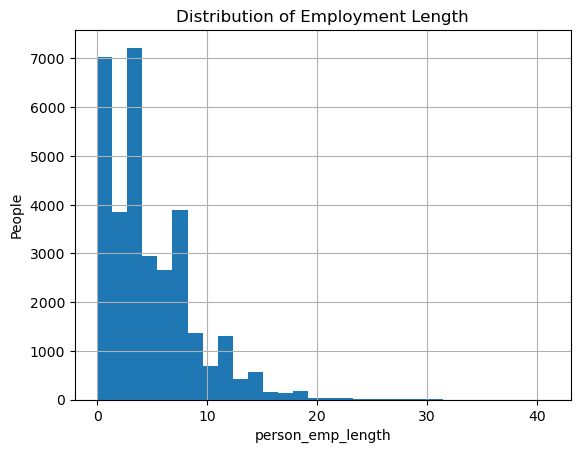

In [13]:
import matplotlib.pyplot as plt

df["person_emp_length"].hist(bins=30)

plt.xlabel("person_emp_length")
plt.ylabel("People")
plt.title("Distribution of Employment Length")

plt.show()

Counting how many people repay the loan

In [14]:
df["loan_status_label"] = df["loan_status"].map({
    0: "Repaid",
    1: "Default"
})

df["loan_status_label"].value_counts()

loan_status_label
Repaid     25467
Default     7107
Name: count, dtype: int64

7107 people dont repay the loan

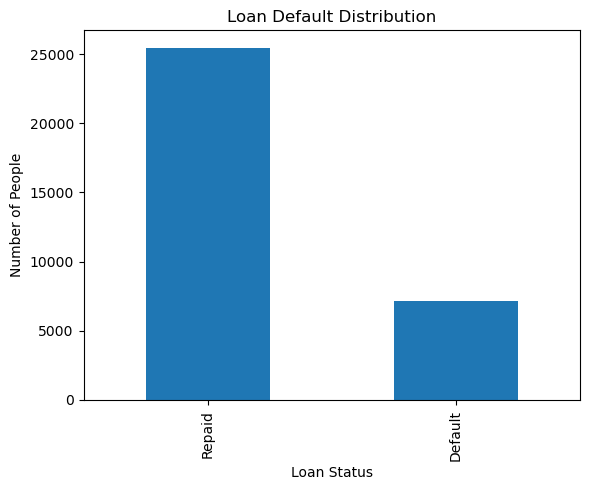

In [15]:
df["loan_status_label"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Loan Status")
plt.ylabel("Number of People")
plt.title("Loan Default Distribution")

plt.show()

Let's go check people with bigger income than mean less often defaulting.

In [16]:
df.groupby("loan_status_label")["person_income"].mean()

loan_status_label
Default    49124.262839
Repaid     70554.030628
Name: person_income, dtype: float64

People with lower average income tend to default more often.

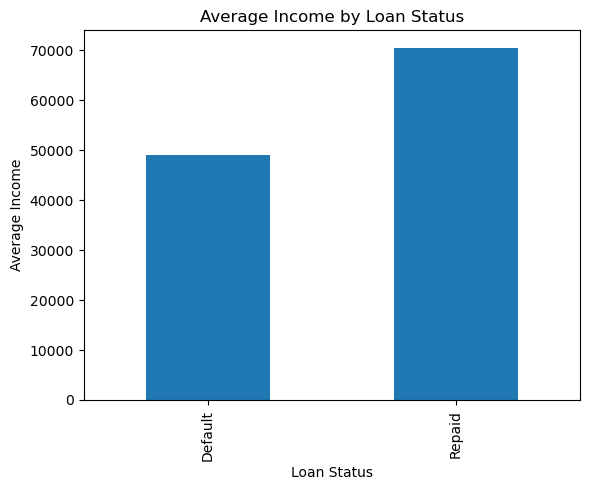

In [17]:
df.groupby("loan_status_label")["person_income"].mean().plot(
    kind="bar"
)

plt.xlabel("Loan Status")
plt.ylabel("Average Income")
plt.title("Average Income by Loan Status")

plt.show()

Analyzing the relationship between previous credit defaults and current loan status


In [18]:
df.groupby("loan_status_label")["cb_person_default_on_file"].value_counts()

loan_status_label  cb_person_default_on_file
Default            N                             4936
                   Y                             2171
Repaid             N                            21894
                   Y                             3573
Name: count, dtype: int64

In [19]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

Matrix correlation

In [20]:
corr = numeric_df.corr()

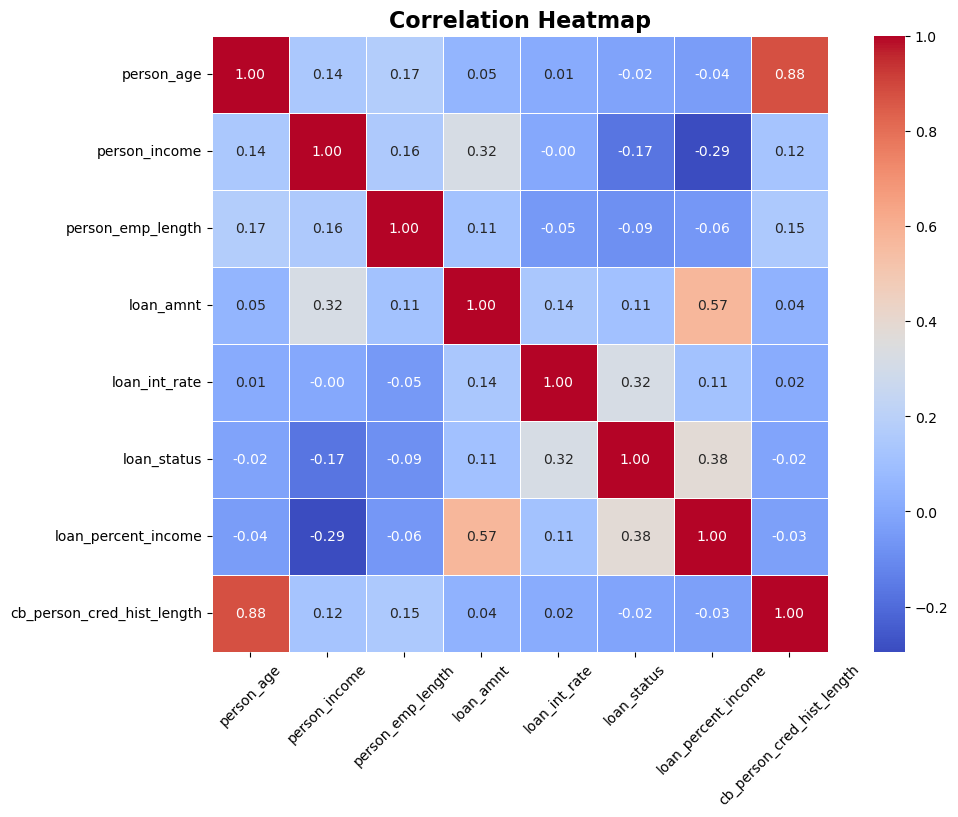

In [21]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

Choose target to create machine learing model

In [22]:
y = df["loan_status"]

In [23]:
features = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "person_age"
]

X = df[features]

typical sklearn to train,validation and test categories

In [24]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

In [26]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (22801, 6)
Validation: (3258, 6)
Test: (6515, 6)


The dataset was divided into three subsets:

- Training set: 22,801 observations
- Validation set: 3,258 observations
- Test set: 6,515 observations

StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model_regression = LogisticRegression()

In [29]:
model_regression.fit(X_train_scaled, y_train)

LogisticRegression()

In [30]:
y_val_pred = model_regression.predict(X_val_scaled)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8339472068753837


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[2423  124]
 [ 417  294]]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2547
           1       0.70      0.41      0.52       711

    accuracy                           0.83      3258
   macro avg       0.78      0.68      0.71      3258
weighted avg       0.82      0.83      0.82      3258



The Logistic Regression model achieved an accuracy of approximately 83% on the validation dataset.

The model performed very well in identifying customers who repaid their loans, achieving a recall of 95% for the non-default class. However, the model achieved a lower recall score (41%) for loan defaults, meaning that many default cases were not detected correctly.

This behavior is likely caused by class imbalance in the dataset, where the majority of customers successfully repaid their loans. Despite this limitation, the model provides a strong baseline for further improvements such as class balancing, feature engineering, and more advanced machine learning algorithms.


Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [35]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
y_val_pred_rf = rf_model.predict(X_val)

In [37]:
accuracy_rf = accuracy_score(
    y_val,
    y_val_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8741559238796808


In [38]:
print(classification_report(
    y_val,
    y_val_pred_rf
))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      2547
           1       0.74      0.66      0.69       711

    accuracy                           0.87      3258
   macro avg       0.82      0.80      0.81      3258
weighted avg       0.87      0.87      0.87      3258



The Random Forest model significantly outperformed Logistic Regression on the validation dataset.

The model achieved an accuracy of approximately 87%, compared to 83% for Logistic Regression. More importantly, the recall score for loan defaults improved from 41% to 66%, indicating that the Random Forest model was much more effective at identifying high-risk customers.

These results suggest that Random Forest can capture more complex nonlinear relationships within the credit risk data, making it a stronger candidate for predicting loan defaults.


In [39]:
importance = rf_model.feature_importances_

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [41]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [42]:
print(feature_importance)

               Feature  Importance
2        loan_int_rate    0.244103
3  loan_percent_income    0.236280
0        person_income    0.230773
1            loan_amnt    0.113792
5           person_age    0.091288
4    person_emp_length    0.083764


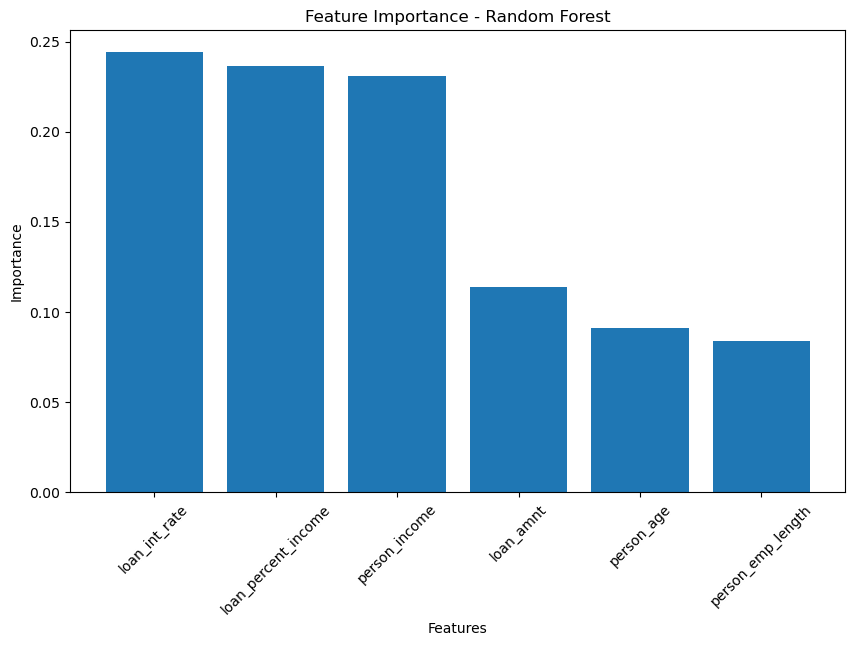

In [43]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.show()

In [44]:
from sklearn.metrics import roc_auc_score

y_val_prob_lr = model_regression.predict_proba(X_val_scaled)[:,1]

roc_auc_lr = roc_auc_score(
    y_val,
    y_val_prob_lr
)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.8436112753925222


In [45]:
y_val_prob_rf = rf_model.predict_proba(X_val)[:,1]

roc_auc_rf = roc_auc_score(
    y_val,
    y_val_prob_rf
)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.8968856662122009


In [46]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

model_results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.833947,0.843611
1,Random Forest,0.874156,0.896886


Model performance was evaluated using ROC-AUC, a metric commonly used in credit risk modelling.

The Logistic Regression model achieved a ROC-AUC score of 0.844, indicating strong predictive performance. However, the Random Forest model achieved a higher ROC-AUC score of 0.897, demonstrating a superior ability to distinguish between customers who are likely to default and those who are likely to repay their loans.

Based on the validation results, Random Forest was selected as the best-performing model for this project.


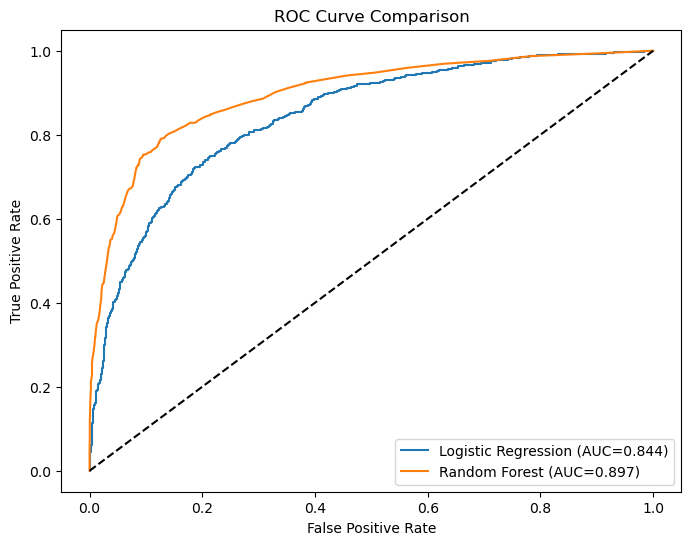

In [50]:
import os
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_val_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC={roc_auc_lr:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC={roc_auc_rf:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

os.makedirs("../images", exist_ok=True)

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2547
           1       0.74      0.64      0.68       711

    accuracy                           0.87      3258
   macro avg       0.82      0.79      0.80      3258
weighted avg       0.87      0.87      0.87      3258

XGBoost ROC-AUC: 0.8993526484096178


In [52]:
report_lr = classification_report(y_val, y_val_pred, output_dict=True)
report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True)
report_xgb = classification_report(y_val, y_val_pred_xgb, output_dict=True)

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy, accuracy_rf, accuracy_score(y_val, y_val_pred_xgb)],
    "Default Recall": [
        report_lr["1"]["recall"],
        report_rf["1"]["recall"],
        report_xgb["1"]["recall"]
    ],
    "Default F1-score": [
        report_lr["1"]["f1-score"],
        report_rf["1"]["f1-score"],
        report_xgb["1"]["f1-score"]
    ],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf, roc_auc_score(y_val, y_val_prob_xgb)]
})

model_results

,Model,Accuracy,Default Recall,Default F1-score,ROC-AUC
0,Logistic Regression,0.833947,0.413502,0.520815,0.843611
1,Random Forest,0.874156,0.655415,0.694486,0.896886
2,XGBoost,0.871700,0.638537,0.684766,0.899353


In [53]:
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred))
print("Final Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5094
           1       0.76      0.59      0.67      1421

    accuracy                           0.87      6515
   macro avg       0.83      0.77      0.79      6515
weighted avg       0.86      0.87      0.86      6515

Final Test ROC-AUC: 0.8852103328639038


In [54]:
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred))
print("Final Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93      5094
           1       0.78      0.63      0.70      1421

    accuracy                           0.88      6515
   macro avg       0.84      0.79      0.81      6515
weighted avg       0.88      0.88      0.88      6515

Final Test ROC-AUC: 0.8890382276951234


Final model selection

Although XGBoost achieved slightly higher ROC-AUC on the validation set, Random Forest demonstrated better generalization on the independent test set.

Random Forest achieved:

* Accuracy: 88%
* Recall: 63%
* F1-score: 0.70
* ROC-AUC: 0.890

Therefore, Random Forest was selected as the final model for credit risk prediction.
